# 02 — Analysis (Run-All, no API key needed)

Recomputes **every number and figure in the paper** from the frozen CSVs.
Works locally (repo checkout) or on Google Colab (clones the public repo).


In [1]:
import os, pathlib, sys
if not pathlib.Path('../results/raw_answers.csv').exists() and not pathlib.Path('results/raw_answers.csv').exists():
    # Colab: fetch the public repo
    os.system('git clone https://github.com/arshhn/honest-finance-qa repo_hfq')
    ROOT = pathlib.Path('repo_hfq')
else:
    ROOT = pathlib.Path('..') if pathlib.Path('../results').exists() else pathlib.Path('.')
sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT.resolve())

repo root: D:\git\honest-finance-qa


In [2]:
import importlib, analyze
importlib.reload(analyze)
analyze.main()   # writes metrics_summary.csv, conformal.csv, fsq_table.csv + figures

D:\git\honest-finance-qa\notebooks\..\src\analyze.py:75: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["same_window"] = out.same_window.fillna(False)
D:\git\honest-finance-qa\src\analyze.py:75: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["same_window"] = out.same_window.fillna(False)


metrics_summary.csv, conformal.csv, multiseed.csv, fsq_table.csv, figures/ written

== headline ==
metric             accuracy_all  accuracy_all_cp_hi  accuracy_all_cp_lo  accuracy_answered  coverage_at_10pct_risk_insample  coverage_at_5pct_risk_insample  ece_m1_deciles  m2_coverage_eligible  m2_risk  m2_valid_pairs  m3_coverage_eligible  m3_eligible  m3_risk  matched_cov_risk_m1      n  refusal_rate  scale_error_rate
model  setting                                                                                                                                                                                                                                                                                                                    
haiku  closedbook         0.187               0.258               0.128              0.406                              NaN                             NaN             NaN                   NaN      NaN             NaN                   NaN          NaN  

## Headline tables

In [3]:
import pandas as pd
summary = pd.read_csv(analyze.ROOT / 'results' / 'metrics_summary.csv')
summary.pivot_table(index=['model','setting'], columns='metric', values='value').round(3)

metric             accuracy_all  accuracy_all_cp_hi  accuracy_all_cp_lo  \
model  setting                                                            
haiku  closedbook         0.187               0.258               0.128   
       oracle             0.827               0.884               0.756   
opus   closedbook         0.687               0.760               0.606   
       oracle             0.913               0.953               0.856   
sonnet closedbook         0.447               0.530               0.366   
       oracle             0.880               0.927               0.817   

metric             accuracy_answered  coverage_at_10pct_risk_insample  \
model  setting                                                          
haiku  closedbook              0.406                              NaN   
       oracle                  0.899                            0.900   
opus   closedbook              0.763                              NaN   
       oracle                  0.919                            0.993   
sonnet closedbook              0.620                              NaN   
       oracle                  0.923                            0.953   

metric             coverage_at_5pct_risk_insample  ece_m1_deciles  \
model  setting                                                      
haiku  closedbook                             NaN             NaN   
       oracle                               0.780           0.046   
opus   closedbook                             NaN             NaN   
       oracle                               0.867           0.043   
sonnet closedbook                             NaN             NaN   
       oracle                               0.807           0.094   

metric             m2_coverage_eligible  m2_risk  m2_valid_pairs  \
model  setting                                                     
haiku  closedbook                   NaN      NaN             NaN   
       oracle                     0.839    0.053           112.0   
opus   closedbook                   NaN      NaN             NaN   
       oracle                     0.936    0.088           109.0   
sonnet closedbook                   NaN      NaN             NaN   
       oracle                     0.821    0.076           112.0   

metric             m3_coverage_eligible  m3_eligible  m3_risk  \
model  setting                                                  
haiku  closedbook                   NaN          NaN      NaN   
       oracle                     0.830         53.0    0.114   
opus   closedbook                   NaN          NaN      NaN   
       oracle                     0.811         53.0    0.070   
sonnet closedbook                   NaN          NaN      NaN   
       oracle                     0.811         53.0    0.070   

metric             matched_cov_risk_m1      n  refusal_rate  scale_error_rate  
model  setting                                                                 
haiku  closedbook                  NaN  150.0         0.540             0.007  
       oracle                    0.047  150.0         0.080             0.000  
opus   closedbook                  NaN  150.0         0.100             0.000  
       oracle                    0.033  150.0         0.007             0.000  
sonnet closedbook                  NaN  150.0         0.280             0.000  
       oracle                    0.046  150.0         0.047             0.000

In [4]:
pd.read_csv(analyze.ROOT / 'results' / 'conformal.csv').round(3)

,model,method,target,rule,threshold,tune_risk,coverage,n_answered,n_excluded_by_threshold,realized_risk,cp_lo,cp_hi,degenerate
0,haiku,M1,0.05,plugin,97,0.000,0.187,14,57,0.000,0.000,0.232,True
1,haiku,M1,0.05,certified,NaN,NaN,0.000,0,0,NaN,NaN,NaN,True
2,haiku,M1,0.10,plugin,62,0.090,0.947,71,0,0.113,0.050,0.210,False
3,haiku,M1,0.10,certified,NaN,NaN,0.000,0,0,NaN,NaN,NaN,True
4,haiku,M2,0.05,plugin,NaN,0.083,0.000,0,0,NaN,NaN,NaN,True
5,haiku,M2,0.05,certified,NaN,0.083,0.000,0,0,NaN,NaN,NaN,True
6,haiku,M2,0.10,plugin,signal,0.083,0.852,46,7,0.022,0.001,0.115,False
7,haiku,M2,0.10,certified,NaN,0.083,0.000,0,0,NaN,NaN,NaN,True
8,haiku,M3,0.05,plugin,NaN,0.059,0.000,0,0,NaN,NaN,NaN,True
9,haiku,M3,0.05,certified,NaN,0.059,0.000,0,0,NaN,NaN,NaN,True


In [5]:
pd.read_csv(analyze.ROOT / 'results' / 'fsq_table.csv').round(3)

,model,n_base,n_pert,n_unans,base_accuracy,base_refusal,robustness_all,robustness_cp_lo,compliance_all,fabrication,...,rob_incomplete,n_incomplete,rob_outofdomain,n_outofdomain,rob_ocr,n_ocr,comp_missingctx,n_missingctx,comp_outofscope,n_outofscope
0,haiku,40,40,38,0.85,0.05,0.825,0.672,1.0,0.0,...,0.8,10,0.875,8,0.9,10,1.0,20,1.0,18
1,sonnet,40,40,40,0.90,0.05,0.875,0.732,1.0,0.0,...,0.9,10,0.875,8,1.0,10,1.0,20,1.0,20
2,opus,40,40,40,0.95,0.00,0.900,0.763,1.0,0.0,...,0.9,10,0.875,8,0.8,10,1.0,20,1.0,20


## Figures

calibration_haiku.png


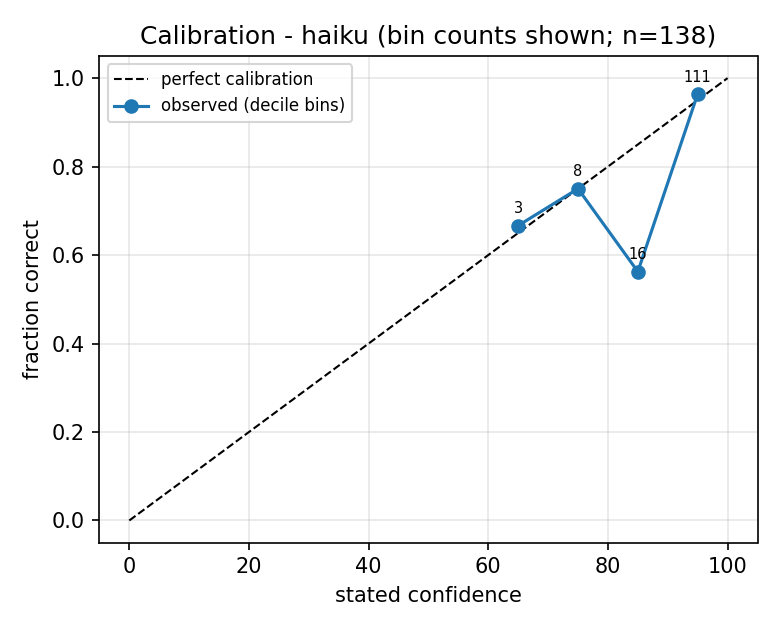

calibration_opus.png


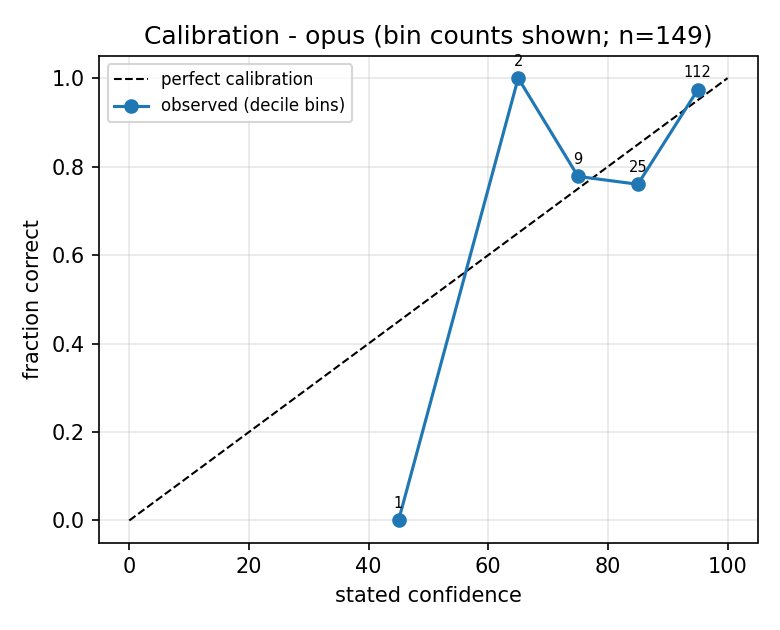

calibration_sonnet.png


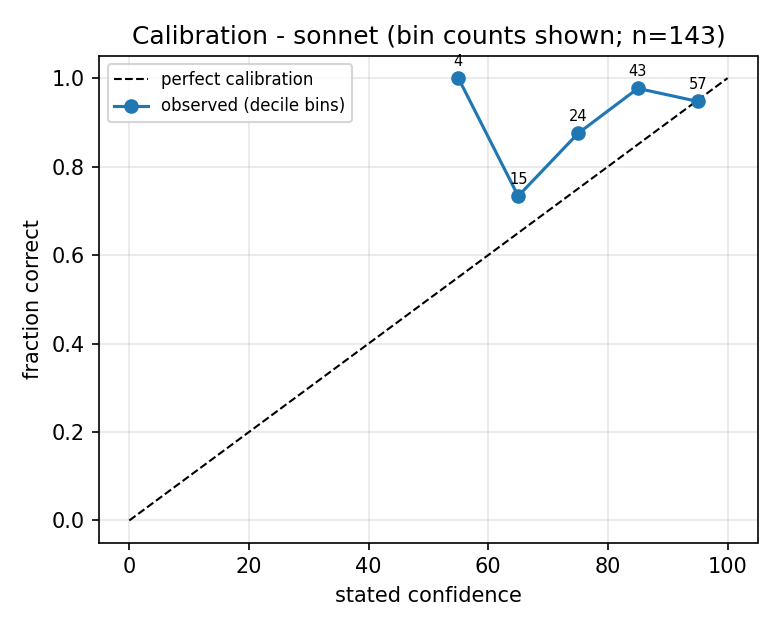

fsq_robustness_compliance.png


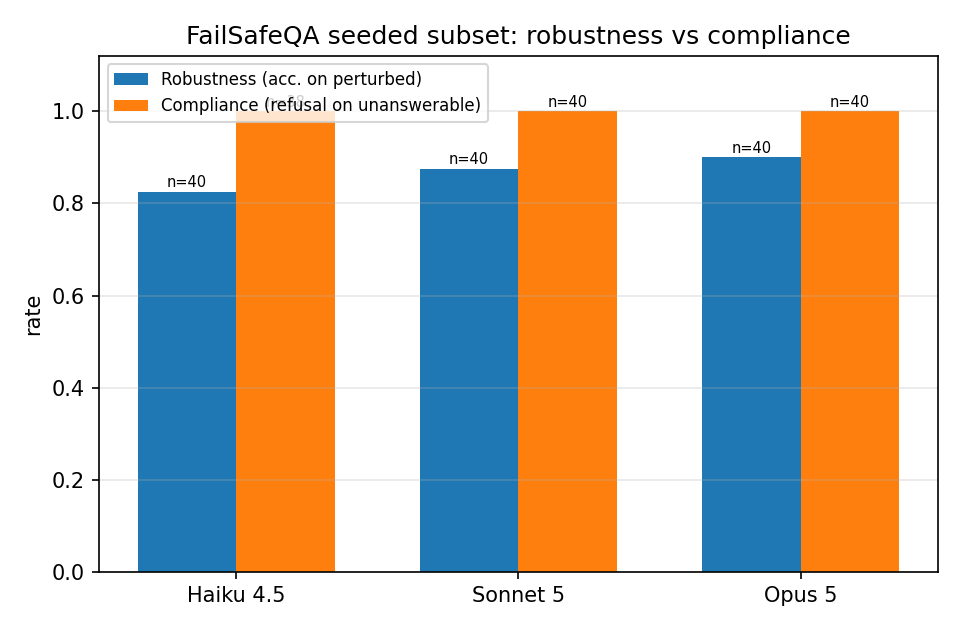

risk_coverage_haiku.png


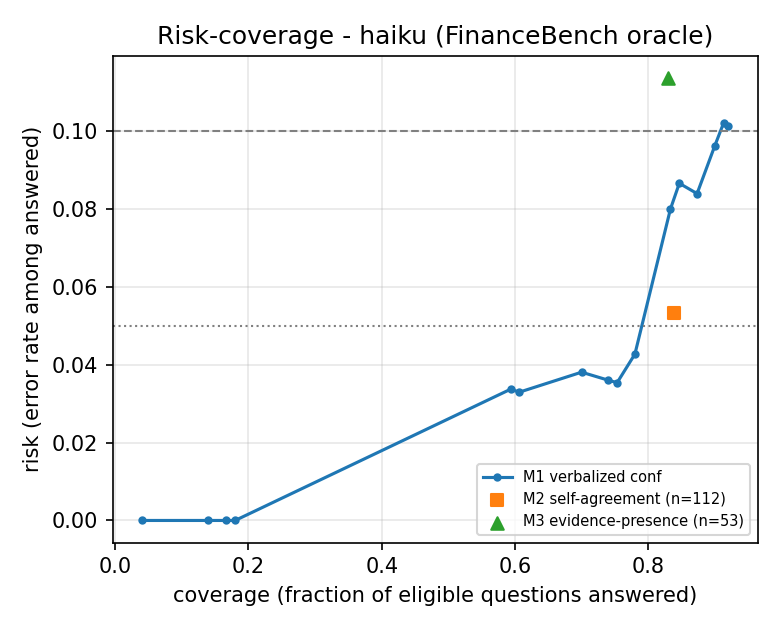

risk_coverage_opus.png


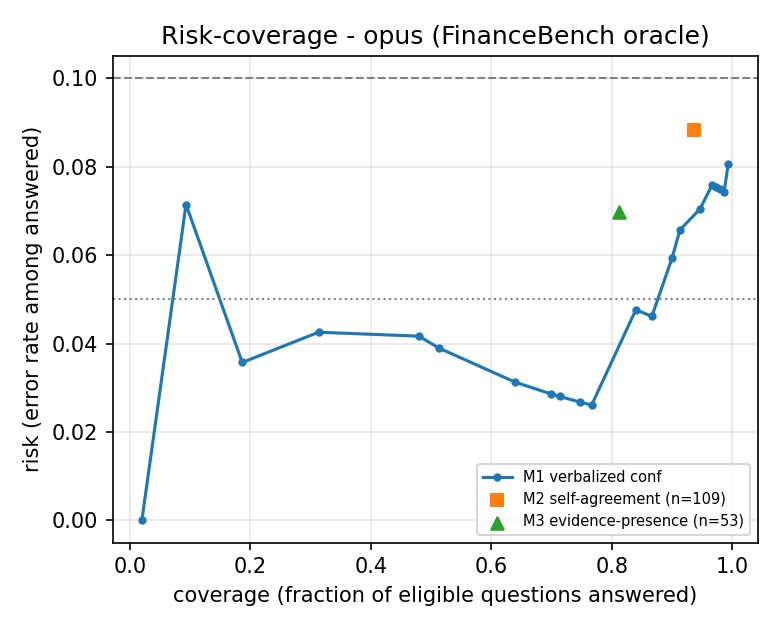

risk_coverage_sonnet.png


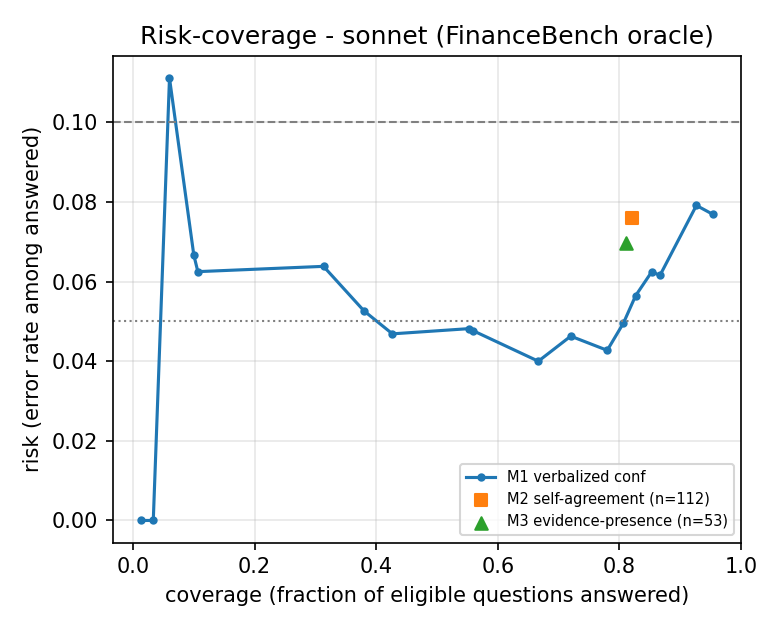

In [6]:
from IPython.display import Image, display
for p in sorted((analyze.ROOT / 'results' / 'figures').glob('*.png')):
    print(p.name); display(Image(str(p)))